# Display a map of google

In [18]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow
import pandas as pd

In [3]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")

roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

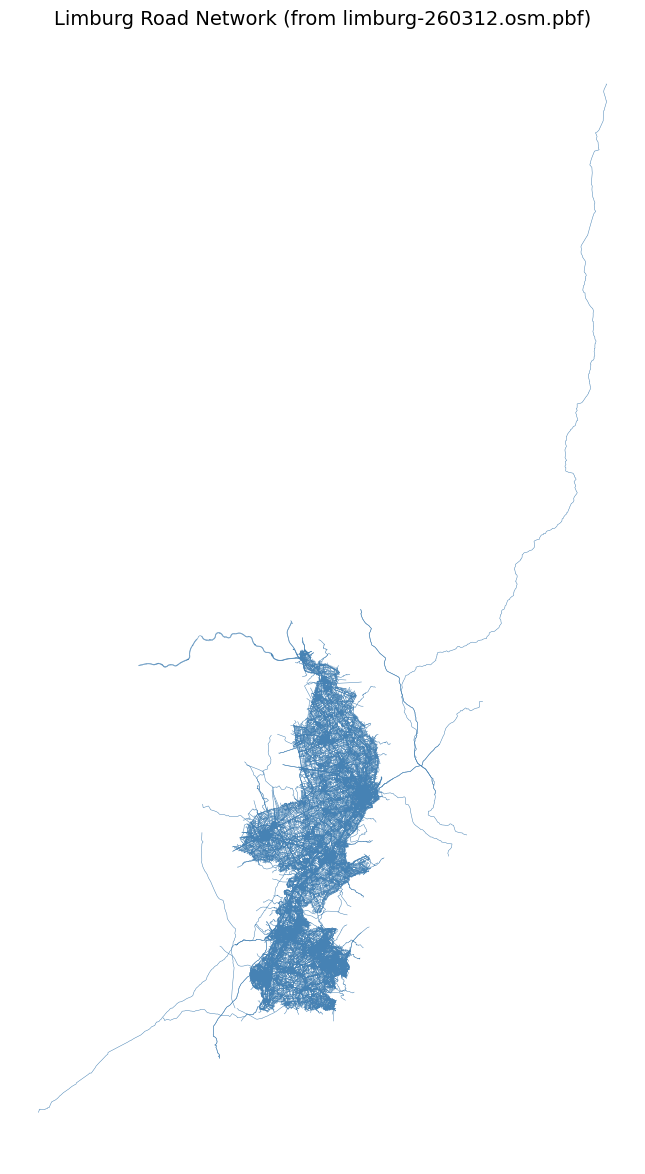

In [4]:
fig, ax = plt.subplots(figsize=(12, 12))
roads.plot(ax=ax, linewidth=0.35, color="steelblue")
ax.set_title("Limburg Road Network (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

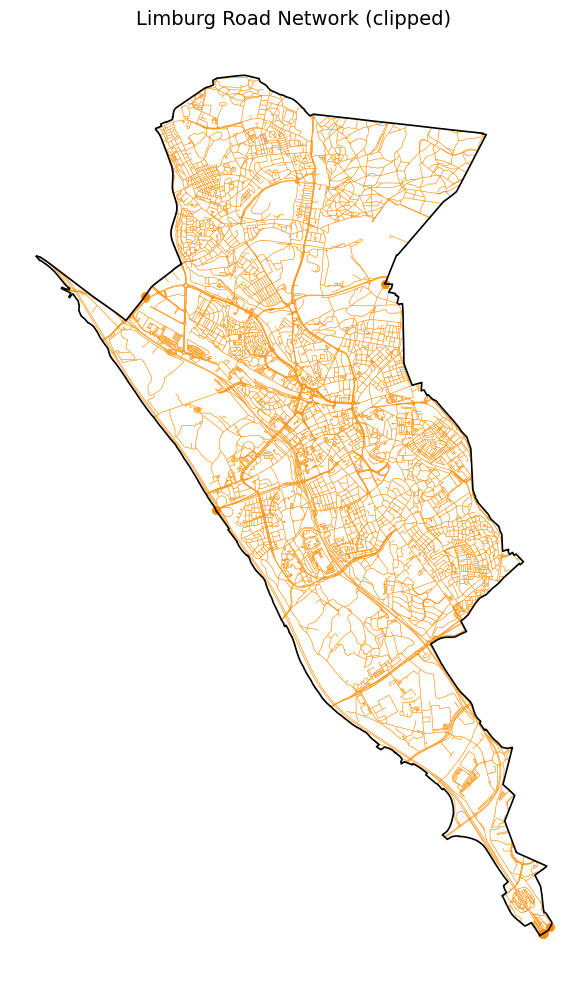

Road segments after clipping: 10,181


In [5]:
import osmnx as ox

# Build Limburg boundary and clip roads to it
limburg_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands")
limburg_boundary = limburg_boundary.to_crs(roads.crs)
limburg_geom = limburg_boundary.union_all()

# Keep road-like lines and cut segments at the Limburg border
if "highway" in roads.columns:
    roads_for_plot = roads[roads["highway"].notna()].copy()
else:
    roads_for_plot = roads.copy()

roads_limburg = gpd.clip(roads_for_plot, limburg_geom)
roads_limburg = roads_limburg[roads_limburg.geometry.notna() & ~roads_limburg.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
roads_limburg.plot(ax=ax, linewidth=0.45, color="darkorange")
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("Limburg Road Network (clipped)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Road segments after clipping: {len(roads_limburg):,}")

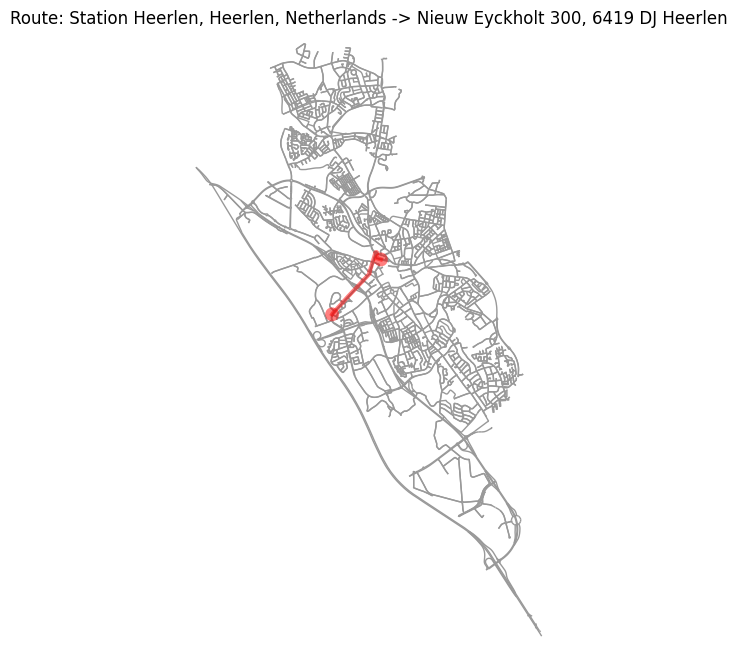

In [6]:
# Set your route endpoints here
start_point = "Station Heerlen, Heerlen, Netherlands"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

In [7]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")



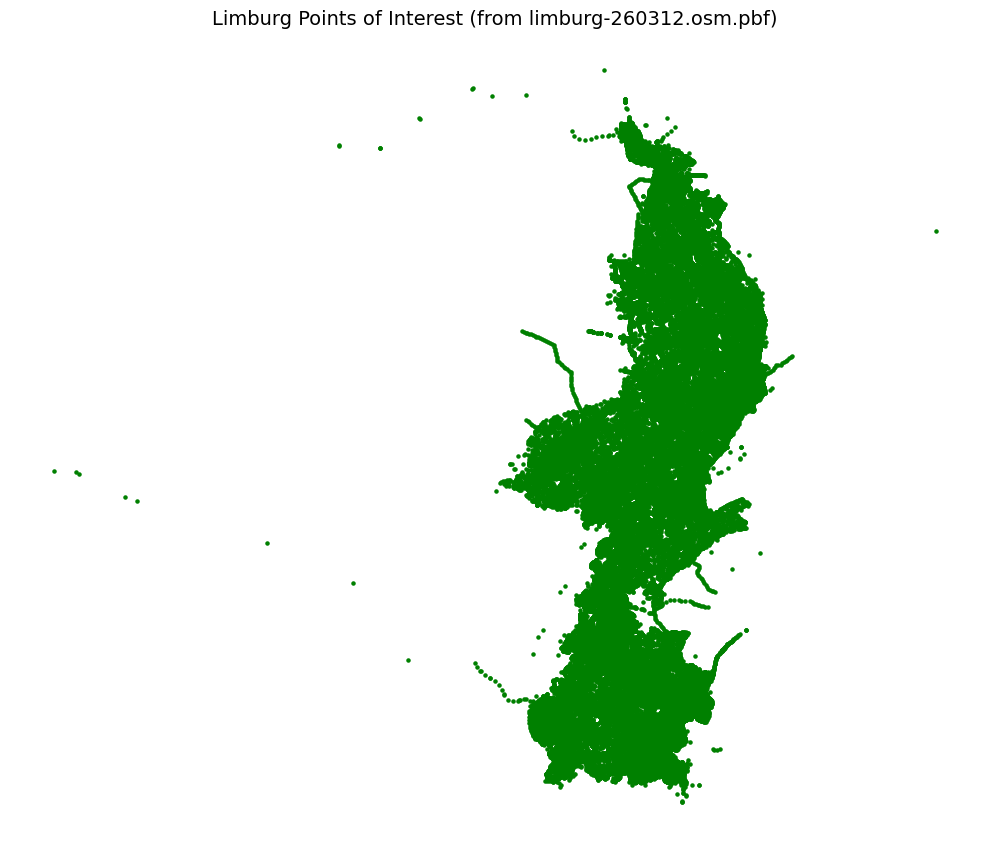

In [8]:
points = gpd.read_file(pbf_path, layer="points")

# Project for cleaner plotting in meters
points = points.to_crs(epsg=3857)

points.plot(figsize=(10, 10), color="green", markersize=5)
plt.title("Limburg Points of Interest (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

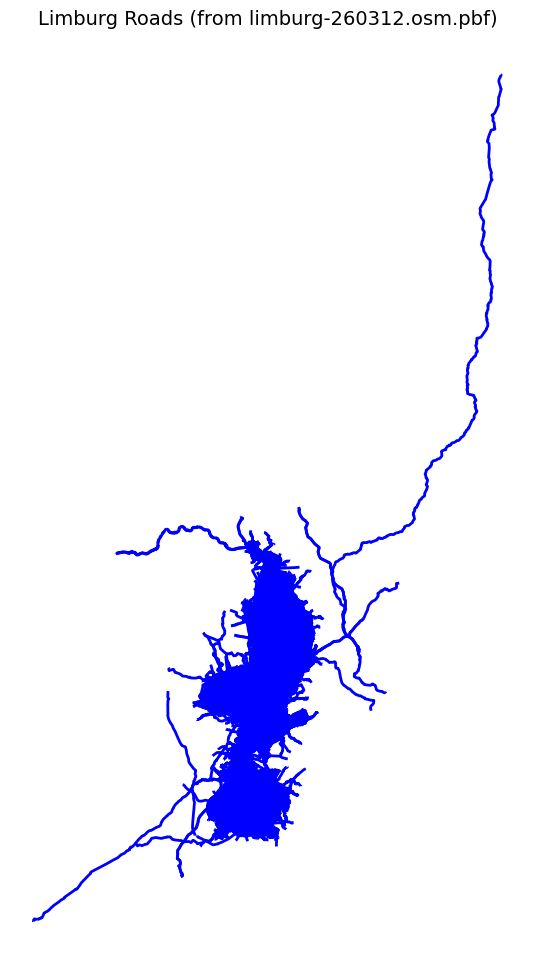

In [9]:
roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

roads.plot(figsize=(10, 10), color="blue", linewidth=2)
plt.title("Limburg Roads (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,geometry
0,4443691,NaN,footway,NaN,NaN,NaN,NaN,NaN,0,"""surface""=>""paving_stones""","LINESTRING (670006.311 6578139.577, 670003.951..."


In [11]:
desired_columns = [
    "osm_id", "name", "highway", "waterway", "aerialway", 
    "barrier", "man_made", "railway", "z_order", "other_tags"
]

roads = gpd.read_file(
    pbf_path, 
    layer="lines", 
    engine="pyogrio",
    columns=desired_columns,
    use_arrow=False
)

roads_with_speed = roads[roads['other_tags'].str.contains('maxspeed', na=False)].copy()
roads_with_speed['speed_limit'] = roads_with_speed['other_tags'].str.extract(r'"maxspeed"=>"(\d+)"')

roads_with_speed = roads_with_speed[desired_columns + ['speed_limit', 'geometry']].copy()

In [12]:
roads_with_speed.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
14,4578867,Von-Byland-Straße,residential,NaN,NaN,NaN,NaN,NaN,3,"""lane_markings""=>""no"",""maxspeed""=>""30"",""zone:m...",30,"LINESTRING (5.87941 51.02503, 5.87947 51.025, ..."


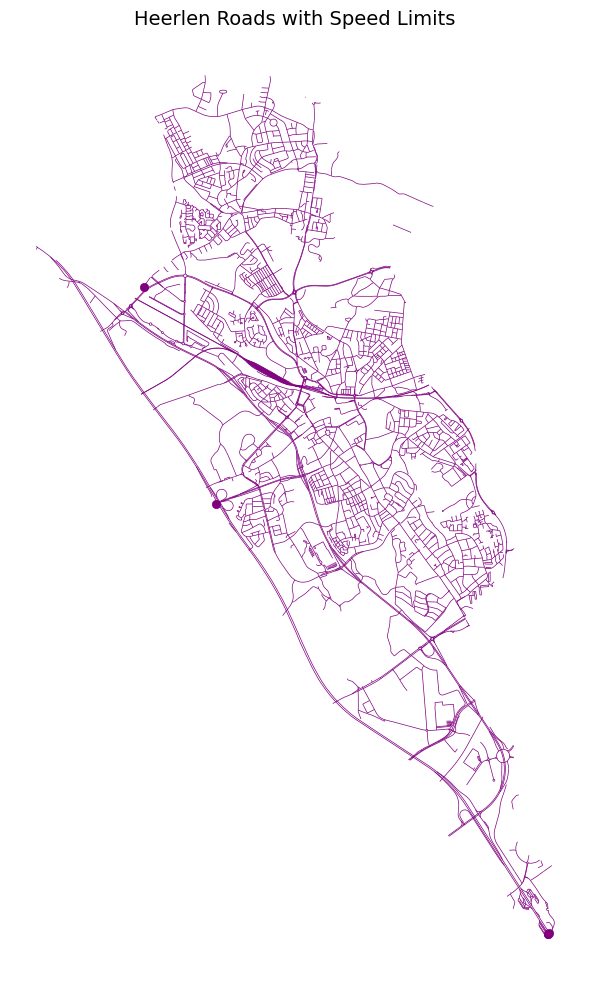

In [13]:
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
ax.set_title("Heerlen Roads with Speed Limits", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [14]:
roads_heerlen.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


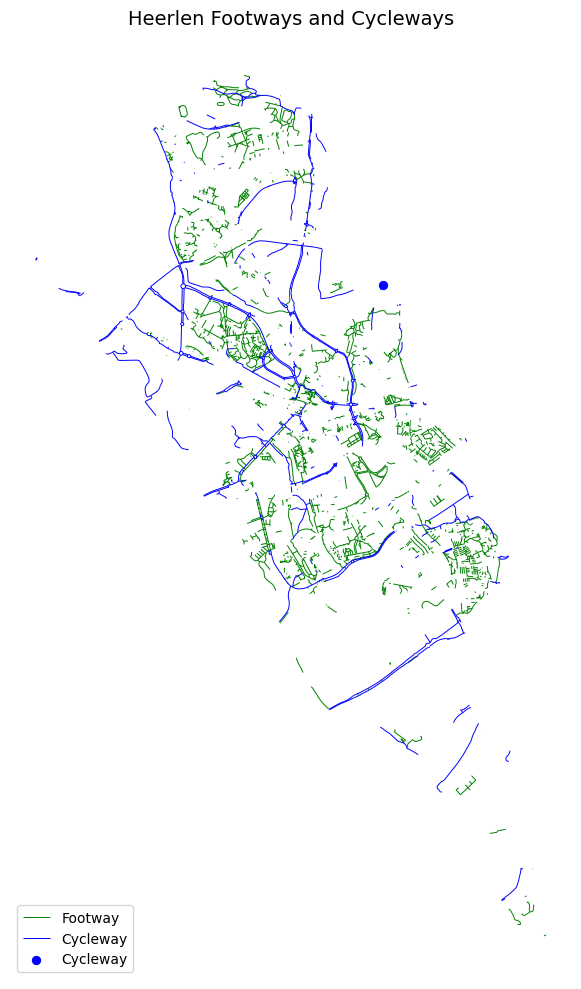

In [15]:
# Add cycleways and footways in Heerlen: footways green, cycleways blue

footway_roads = roads[roads['highway'] == 'footway'].copy()
footway_roads = footway_roads[footway_roads.geometry.notna() & ~footway_roads.geometry.is_empty].copy()

cycleway_roads = roads[roads['highway'] == 'cycleway'].copy()
cycleway_roads = cycleway_roads[cycleway_roads.geometry.notna() & ~cycleway_roads.geometry.is_empty].copy()

heerlen_geom = heerlen_boundary.geometry.iloc[0]
footway_heerlen = gpd.clip(footway_roads, heerlen_geom)
cycleway_heerlen = gpd.clip(cycleway_roads, heerlen_geom)

fig, ax = plt.subplots(figsize=(10, 10))
footway_heerlen.plot(ax=ax, linewidth=0.7, color="green", label="Footway")
cycleway_heerlen.plot(ax=ax, linewidth=0.7, color="blue", label="Cycleway")
ax.set_title("Heerlen Footways and Cycleways", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [22]:
# load in this csv clients.csv
clients = pd.read_csv("clients.csv")

addresses = clients["address"].copy()
addresses.head(3)

0    A gen Giezen 10 6418 OY Heerlen
1       Caumerweg 30 6418 IW Heerlen
2       Kortstraat 7 6411 CW Heerlen
Name: address, dtype: str

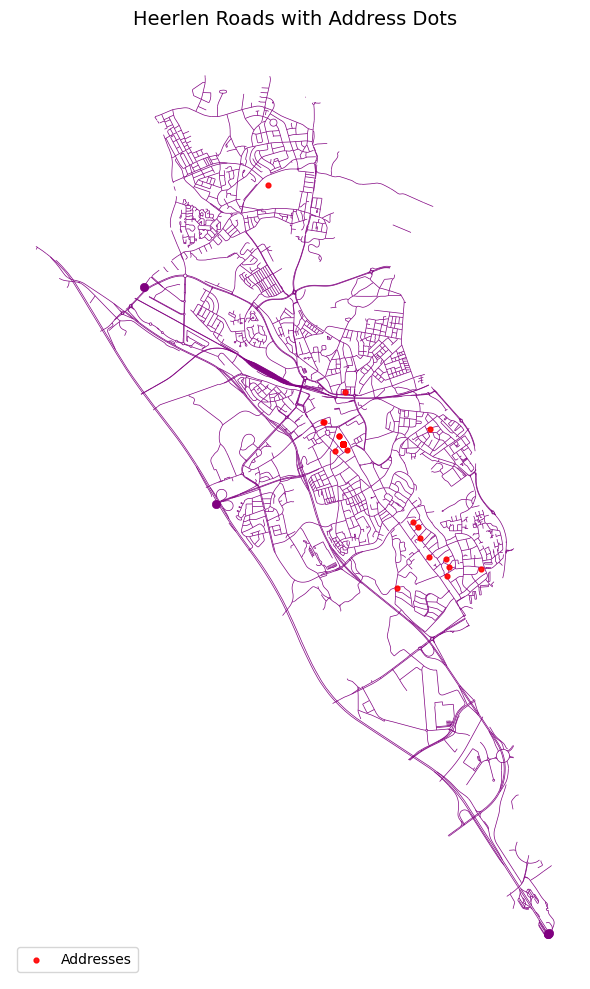

In [ ]:
# Plot Heerlen roads and geocoded client addresses as dots
clients = pd.read_csv("clients.csv")

def geocode_address(address: str):
    query = address if "netherlands" in address.lower() else f"{address}, Heerlen, Netherlands"
    try:
        lat, lon = ox.geocode(query)
        return pd.Series({"latitude": lat, "longitude": lon, "geocode_ok": True})
    except Exception:
        return pd.Series({"latitude": None, "longitude": None, "geocode_ok": False})

geocoded = clients["address"].apply(geocode_address)
clients_geocoded = pd.concat([clients, geocoded], axis=1)
clients_geocoded_ok = clients_geocoded[clients_geocoded["geocode_ok"]].copy()

address_points = gpd.GeoDataFrame(
    clients_geocoded_ok,
    geometry=gpd.points_from_xy(clients_geocoded_ok["longitude"], clients_geocoded_ok["latitude"]),
    crs="EPSG:4326",
)

heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

address_points = address_points.to_crs(roads_with_speed.crs)
address_points_heerlen = gpd.clip(address_points, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
address_points_heerlen.plot(
    ax=ax,
    color="red",
    markersize=12,
    alpha=0.9,
    zorder=3,
    label="Addresses",
)

ax.set_title("Heerlen Roads with Geocoded Address Dots", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Addresses in clients.csv: {len(clients)}")
print(f"Geocoded successfully: {len(clients_geocoded_ok)}")
print(f"Failed geocoding: {len(clients) - len(clients_geocoded_ok)}")
print(f"Points inside Heerlen after clipping: {len(address_points_heerlen)}")

In [25]:
# Diagnostics: why not all 100 dots are visible
clients_coords_diag = pd.read_csv("clients_with_coords.csv")

total_rows = len(clients_coords_diag)
valid_coord_mask = clients_coords_diag[["latitude", "longitude"]].notna().all(axis=1)
valid_rows = int(valid_coord_mask.sum())

diag_points = gpd.GeoDataFrame(
    clients_coords_diag.loc[valid_coord_mask].copy(),
    geometry=gpd.points_from_xy(
        clients_coords_diag.loc[valid_coord_mask, "longitude"],
        clients_coords_diag.loc[valid_coord_mask, "latitude"],
    ),
    crs="EPSG:4326",
).to_crs(roads_with_speed.crs)

heerlen_geom = heerlen_boundary.geometry.iloc[0]
inside_heerlen_mask = diag_points.within(heerlen_geom)
inside_heerlen = int(inside_heerlen_mask.sum())
outside_heerlen = int((~inside_heerlen_mask).sum())

xmin, ymin, xmax, ymax = roads_heerlen.total_bounds
within_map_extent_mask = diag_points.geometry.x.between(xmin, xmax) & diag_points.geometry.y.between(ymin, ymax)
inside_map_extent = int(within_map_extent_mask.sum())
outside_map_extent = int((~within_map_extent_mask).sum())

unique_coord_count = int(
    diag_points[["latitude", "longitude"]].drop_duplicates().shape[0]
)
duplicate_count = int(len(diag_points) - unique_coord_count)

print(f"Rows in CSV: {total_rows}")
print(f"Rows with valid lat/lon loaded as points: {valid_rows}")
print(f"Points inside Heerlen boundary: {inside_heerlen}")
print(f"Points outside Heerlen boundary: {outside_heerlen}")
print(f"Points inside current map extent: {inside_map_extent}")
print(f"Points outside current map extent: {outside_map_extent}")
print(f"Unique coordinate pairs: {unique_coord_count}")
print(f"Duplicate coordinate rows (overlapping dots): {duplicate_count}")

if outside_heerlen > 0:
    print("\nSample rows outside Heerlen:")
    print(diag_points.loc[~inside_heerlen_mask, ["name", "address", "latitude", "longitude"]].head(10))

Rows in CSV: 100
Rows with valid lat/lon loaded as points: 100
Points inside Heerlen boundary: 100
Points outside Heerlen boundary: 0
Points inside current map extent: 100
Points outside current map extent: 0
Unique coordinate pairs: 18
Duplicate coordinate rows (overlapping dots): 82


In [27]:
# Show duplicate coordinate values and their matching rows
dup_coords = (
    clients_coords_diag
    .groupby(["latitude", "longitude"], dropna=False)
    .size()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(f"Duplicate coordinate pairs: {len(dup_coords)}")
print(f"Rows involved in duplicates: {int(dup_coords['count'].sum())}")
print("\nDuplicate coordinate values (lat, lon, count):")
display(dup_coords)

dup_rows = (
    clients_coords_diag
    .merge(dup_coords[["latitude", "longitude", "count"]], on=["latitude", "longitude"], how="inner")
    .sort_values(["count", "latitude", "longitude", "name"], ascending=[False, True, True, True])
    .reset_index(drop=True)
)

print("\nRows that share duplicated coordinates:")
display(dup_rows[["name", "address", "latitude", "longitude", "count"]])

Duplicate coordinate pairs: 2
Rows involved in duplicates: 84

Duplicate coordinate values (lat, lon, count):


,latitude,longitude,count
0,50.883650,5.981540,82
1,50.884688,5.980498,2



Rows that share duplicated coordinates:


,name,address,latitude,longitude,count
0,Client 1,A gen Giezen 10 6418 OY Heerlen,50.883650,5.981540,82
1,Client 10,Julianaweg 57 6413 FI Heerlen,50.883650,5.981540,82
2,Client 100,Jacob van Maerlantstraat 2 6416 PZ Heerlen,50.883650,5.981540,82
3,Client 11,Corisbergweg 174 6418 CP Heerlen,50.883650,5.981540,82
4,Client 12,Oliemolenstraat 24 6411 RG Heerlen,50.883650,5.981540,82
...,...,...,...,...,...
79,Client 96,Julianaweg 32 6413 OD Heerlen,50.883650,5.981540,82
80,Client 97,September 1944-straat 97 6418 AP Heerlen,50.883650,5.981540,82
81,Client 99,Palestinastraat 148 6418 BG Heerlen,50.883650,5.981540,82
82,Client 33,Op de Nobel 2 6411 QA Heerlen,50.884688,5.980498,2
